In [1]:
# импортируем библиотеку для визаулизации данных
import matplotlib.pyplot as plt
# импортируем библиотеку для базовых математических расчетов
import math

In [2]:
# Размеры образца, которые нам понадобятся позднее
b0 = 11 # ширина образца по ISO 6892-1:2019
L0 = 50 # начальная длина образца по ISO 6892-1:2019
a0 = 5 # тольщина образца по исходным данным

In [4]:
stroke = [] # пустой список для записи данных о перемещении
load = [] # пустой список для записи данных о силе

# открываем файл с данными
with open ('Логи испытания обр 111.txt', 'r') as file: # 'r' означает, что файл мы октрываем для чения
    for line in file:                                    # для каждой строки в файле мы выполняем следующие действия
        stroke_load = line.split('\t')                   # разделяем строку по табуляции (можно было ничего не писать в скобках 
                                                         # и разделение было бы по любым пробелам). Получаем временный список из двух чисел
        stroke.append(float(stroke_load[1]))             # первое число добавляем в список stroke
        load.append(float(stroke_load[2]))

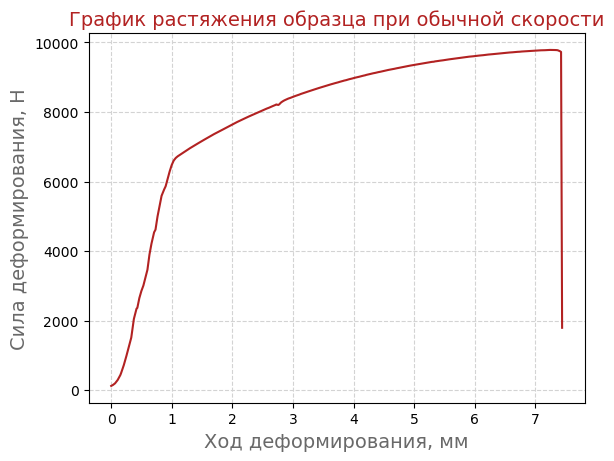

In [24]:
# визуализируем данные с помощью импортированной ранее библиотеки matplotlib

# создаем "базу" для графика
plt.plot (stroke, load, '-', color = 'firebrick')
# Добавляем названия осей
plt.title ('График растяжения образца при обычной скорости',fontsize = 14, color='firebrick')
plt.xlabel ('Ход деформирования, мм', fontsize = 14, color='dimgrey')
plt.ylabel ('Сила деформирования, Н', fontsize = 14, color='dimgrey')
# добавляем для красоты сетку
plt.grid(color='lightgray', linestyle='--')

In [25]:
# Расчет инженерного напряжения
A0 = b0*a0 # расчет площади поперечного сечения образца

sigma_eng = [] # пустой список куда будем записывать значения инженерного напряжения
for i in range (0, len(load)):
    sigma_eng.append(load[i]/A0)

In [26]:
# Расчет инженерной деформации
epsilon_eng = [] # пустой список куда будем записывать значения инженерной деформации
for i in range (0, len(stroke)):
    epsilon_eng.append((stroke[i]/L0)*100)

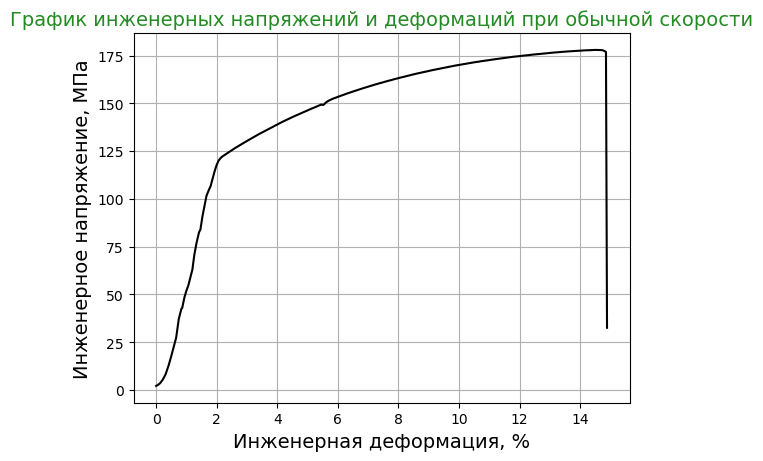

In [27]:
# Визуализируем результаты
# создаем "базу" для графика
plt.plot (epsilon_eng, sigma_eng, '-', color = 'black')
# Добавляем названия осей
plt.title ('График инженерных напряжений и деформаций при обычной скорости',fontsize = 14, color='forestgreen')
plt.xlabel ('Инженерная деформация, %', fontsize = 14)
plt.ylabel ('Инженерное напряжение, МПа', fontsize = 14)
# добавляем для красоты сетку
plt.grid()

In [29]:
# Расчет истинного напряжения и деформации
sigma_true = [] # пустой список куда будем записывать значения истинного напряжения
epsilon_true = [] # пустой список куда будем записывать значения истинной деформации
for i in range (0, len(sigma_eng)):
    sigma_true.append(sigma_eng[i]*(1+epsilon_eng[i]/100))
    epsilon_true.append(math.log(1+epsilon_eng[i]/100))

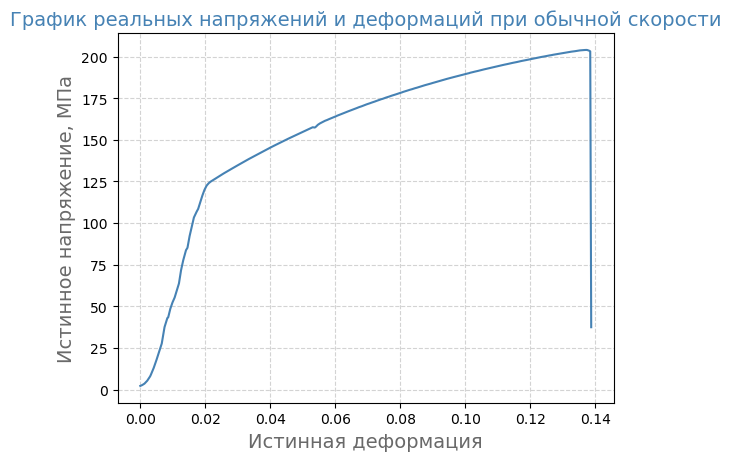

In [30]:
# Визуализируем результаты
# создаем "базу" для график
plt.plot (epsilon_true, sigma_true, '-', color = 'steelblue')
# Добавляем названия осей
plt.title ('График реальных напряжений и деформаций при обычной скорости',fontsize = 14, color='steelblue')
plt.xlabel ('Истинная деформация', fontsize = 14, color='dimgrey')
plt.ylabel ('Истинное напряжение, МПа', fontsize = 14, color='dimgrey')
# добавляем для красоты сетку
plt.grid(color='lightgray', linestyle='--')